In [153]:
import kagglehub
import os
import pandas as pd


# Retrieving Data

In [154]:
## Download latest version (This may time out if you rerun the project couple times in a short period)
#path = kagglehub.dataset_download("kathir1k/youtube-influencers-data")
#path = os.path.join(path, os.listdir(path)[0])
#print(path)

path= "/Users/emirysaglam/.cache/kagglehub/datasets/kathir1k/youtube-influencers-data/versions/2/Youtube Influencer Analysis - Updated.csv"

In [155]:
# Use this code to find the encoding of the file if you face encoding issues
import chardet

with open(path, "rb") as f:
    result = chardet.detect(f.read(10000))

print(result['encoding'])


Windows-1252


In [156]:
df = pd.read_csv(path, encoding=result['encoding'])
df[["Video Link", "Channel URL", "Date of Video Upload", "Creator Name"]]

,Video Link,Channel URL,Date of Video Upload,Creator Name
0,https://www.youtube.com/watch?v=_0fUOJ55gis,https://www.youtube.com/c/sriharick,7/29/2022,srihari ck
1,https://www.youtube.com/watch?v=_70MSLPRfZI,https://www.youtube.com/c/ChaibisketTelugu,5/22/2022,Chai Bisket
2,https://www.youtube.com/watch?v=_8gfCdt3H00&t=87s,https://www.youtube.com/channel/UCcIUnCsBfONvb...,2/9/2021,Virda Warsi
3,https://www.youtube.com/watch?v=_CkFNJgKsFs,https://www.youtube.com/c/trtworld,9/13/2022,TRT
4,https://www.youtube.com/watch?v=_GFkHA5EZdE,Vogue - YouTube,3/21/2017,Vogue
...,...,...,...,...
900,https://www.youtube.com/watch?v=GS18WawA-t0,https://www.youtube.com/c/SahilOnlineTVnews,9/29/2022,Sahil Online TV News
901,https://www.youtube.com/watch?v=_tc_APkjH2Q,https://www.youtube.com/sahilonline,8/6/2017,Sahil Online TV News
902,https://www.youtube.com/watch?v=Xfj4osSYfhU,https://www.youtube.com/sahilonline,1/3/2021,Sahil Online Bhatkal
903,https://www.youtube.com/watch?v=mGEHqwVz0eI,https://www.youtube.com/sahilonline,3/6/2022,Sahil Online Bhatkal


# Setting Theme

In [157]:
import matplotlib.pyplot as plt
from matplotlib import rcParams, font_manager as fm
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns


font_path = "/Users/emirysaglam/Library/Fonts/HankenGrotesk-VariableFont_wght.ttf"
fm.fontManager.addfont(font_path)
font_name = fm.FontProperties(fname=font_path).get_name()

rcParams['font.family'] = font_name

yt_palette = {
    "black": "#282828",
    "red": "#FF0000",
    "yellow": "#FBD704",
    "blue": "#10D8B8",
    "af_blue": "#6A8EAE",
    "purple": "#261D44",

}
cmap = LinearSegmentedColormap.from_list("red_white_black", [ "#282828", "#FFFFFF","#FF0000"])

In [158]:

def set_plot_theme():
   
    plt.rcParams['font.size'] = 10              
    plt.rcParams['font.family'] = font_name 
    plt.rcParams['axes.labelcolor'] = yt_palette["black"] 
    plt.rcParams['axes.titlesize'] = 11        
    plt.rcParams['axes.titleweight'] = 'bold'  
    plt.rcParams['xtick.labelsize'] = 0  
    plt.rcParams['ytick.labelsize'] = 0
    plt.rcParams['legend.fontsize'] = 11   
    plt.rcParams['figure.titlesize'] = 14    
    plt.rcParams['figure.facecolor'] = '#FFFFFF'


    sns.set_theme(style='white')           
    sns.set_context("notebook", font_scale=1.1) 
    sns.set_palette(list(yt_palette.values()))
     
    plt.rcParams['axes.spines.top'] = False
    plt.rcParams['axes.spines.right'] = False
    plt.rcParams['axes.spines.left'] = False
    plt.rcParams['axes.spines.bottom'] = False

set_plot_theme()


# Data Manupilation

In [159]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 905 entries, 0 to 904
Data columns (total 24 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Video Link                             905 non-null    object 
 1   Video Views                            905 non-null    object 
 2   Video Title                            905 non-null    object 
 3   Channel URL                            905 non-null    object 
 4   Creator Name                           894 non-null    object 
 5   Creator Gender                         591 non-null    object 
 6   Total Channel Subcribers               905 non-null    object 
 7   Total Chanel Views                     905 non-null    object 
 8   Duration of Video                      905 non-null    object 
 9   Duration in Seconds                    905 non-null    object 
 10  Date of Video Upload                   905 non-null    object 
 11  No of 

In [160]:
# Remove unnecessary columns
df.drop(columns=['Video Link','Intern Who Collected the Data',"Video Title"], inplace=True)

## String to Numeric

Some columns contain numeric values stored as strings. We are converting these columns to numeric types.

In [161]:
df[["Video Views","Total Channel Subcribers","Total Chanel Views","Duration in Seconds","No of Comments"]]

,Video Views,Total Channel Subcribers,Total Chanel Views,Duration in Seconds,No of Comments
0,"146,059",40200,7964284,"1,841.00",419
1,"231,969",920000,137535681,864.00,189
2,878,458,72945,492.00,0
3,"9,965",1680000,541653219,66.00,77
4,"39,780,561",12100000,3600496171,460.00,28221
...,...,...,...,...,...
900,"6,892",594000,129926690,827.00,15
901,"16,554",594000,129926690,404.00,0
902,"32,798",23500,5104872,384.00,0
903,"1,503",23500,5104872,279.00,0


In [162]:
# Clean numeric columns by removing commas and converting to numeric type
df['Video Views'] = df['Video Views'].str.replace(',', '')
df['Video Views'] = pd.to_numeric(df['Video Views'], errors='coerce')


df['Total Channel Subcribers'] = df['Total Channel Subcribers'].str.replace(',', '')
df['Total Channel Subcribers'] = pd.to_numeric(df['Total Channel Subcribers'], errors='coerce')


df['Total Chanel Views'] = df['Total Chanel Views'].str.replace(',', '')
df['Total Chanel Views'] = pd.to_numeric(df['Total Chanel Views'], errors='coerce')


df['Duration in Seconds'] = df['Duration in Seconds'].str.replace(',', '')
df['Duration in Seconds'] = pd.to_numeric(df['Duration in Seconds'], errors='coerce')

df['No of Comments'] = df['No of Comments'].str.replace(',', '')
df['No of Comments'] = pd.to_numeric(df['No of Comments'], errors='coerce')



In [163]:
# Convert 'Premiered or Not' to binary (1 for 'Yes', 0 for 'No')
df['Premiered or Not'] = df['Premiered or Not'].str.strip().str.lower().map({'yes': 1, 'no': 0})

In [164]:
df.describe()

,Video Views,Total Channel Subcribers,Total Chanel Views,Duration in Seconds,No of Likes,Hashtags,No of Comments,Maximum Quality of the Video,No of Videos the Channel,No of Playlist,Premiered or Not,Community Engagement (Posts per week)
count,9.050000e+02,9.030000e+02,8.960000e+02,905.000000,9.040000e+02,905.000000,9.050000e+02,905.000000,905.000000,896.000000,905.000000,905.000000
mean,5.447910e+07,1.043915e+07,2.235640e+09,1927.761326,5.840101e+05,1.030939,4.558636e+04,1227.712707,4962.866298,82.246652,0.111602,4.516022
std,4.002179e+08,2.410166e+07,1.055352e+10,6395.720819,2.959309e+06,1.835350,4.786907e+05,419.254719,24193.140397,446.041267,0.315051,19.377195
min,2.300000e+01,3.400000e+01,3.600000e+01,0.000000,0.000000e+00,0.000000,0.000000e+00,240.000000,1.000000,0.000000,0.000000,0.000000
25%,2.013700e+05,3.270000e+05,3.599062e+07,314.000000,5.475000e+03,0.000000,2.280000e+02,1080.000000,150.000000,6.000000,0.000000,0.000000
50%,1.293867e+06,2.100000e+06,2.475236e+08,645.000000,3.250000e+04,0.000000,1.221000e+03,1080.000000,389.000000,16.000000,0.000000,1.000000
75%,9.002909e+06,9.300000e+06,1.267778e+09,1034.000000,1.845000e+05,2.000000,7.016000e+03,1080.000000,1393.000000,47.250000,0.000000,3.000000
max,7.990990e+09,3.052000e+08,2.022970e+11,62700.000000,4.900000e+07,28.000000,1.124480e+07,2160.000000,420000.000000,6000.000000,1.000000,341.000000


## Missing Names
Some creator names are missing, so we are extracting them from the channel URLs and filling the 'Creator Name' column with these extracted names.

In [165]:
null_names = df[df["Creator Name"].isnull()][["Creator Name","Channel URL"]].copy()

In [166]:
# Fill missing "Creator Name" by extracting from "Channel URL"
null_names["Creator Name"] = null_names["Channel URL"].apply(lambda x: x.split("/")[-1])
null_names

,Creator Name,Channel URL
88,batmanarkham,https://www.youtube.com/c/batmanarkham
91,cokestudio,https://www.youtube.com/c/cokestudio
101,TrendMaxTV,https://www.youtube.com/c/TrendMaxTV
183,NDTV,https://www.youtube.com/c/NDTV
239,Ashstudio7HD,https://www.youtube.com/c/Ashstudio7HD
275,guardian,https://www.youtube.com/guardian
293,GQ,https://www.youtube.com/c/GQ
322,IMAGINEDRAGONSLIVEE,https://www.youtube.com/c/IMAGINEDRAGONSLIVEE
340,variant,https://www.youtube.com/variant
352,GreatBigStory,https://www.youtube.com/c/GreatBigStory


In [167]:
# Update the original dataframe
df.loc[df["Creator Name"].isnull(), "Creator Name"] = null_names["Creator Name"]

## Manupilating Dates

In [168]:
# Replace - with /
df["Date of Video Upload"] = df["Date of Video Upload"].str.replace("-", "/", regex=False)

# Convert the "Date of Video Upload" column to string, 
# remove leading/trailing spaces, and eliminate non-ASCII characters
df["Date of Video Upload"] = df["Date of Video Upload"].astype(str).str.strip().str.replace(r"[^\x00-\x7F]+", "", regex=True)


# Convert the cleaned string dates into datetime objects
# 'dayfirst=True' assumes the format is day/month/year when parsing
# 'format="mixed"' allows pandas to infer mixed date formats
df["Date of Video Upload"] = pd.to_datetime(df["Date of Video Upload"], dayfirst=True,format='mixed')


We are extracting dates to create additional features for the model. From the bar plot below, we can see that midweek is the most popular time to upload videos.

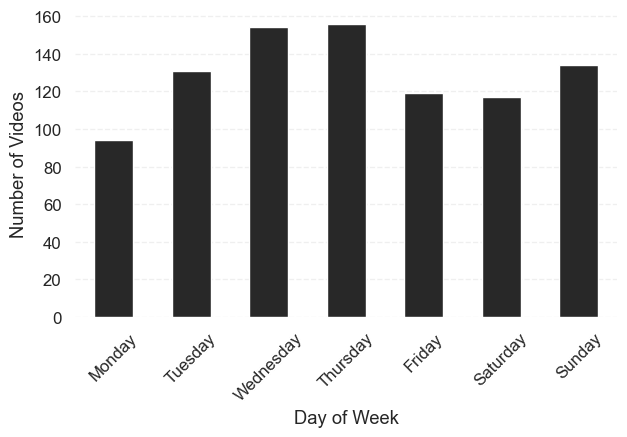

In [169]:

# Extract day of the week
df["DayOfWeek"] = df["Date of Video Upload"].dt.day_name()

# Count occurrences of each day, ensuring all days are represented
day_counts = df["DayOfWeek"].value_counts().reindex(
    ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
)

plt.figure(figsize=(7,4))
day_counts.plot(kind="bar")

plt.xlabel("Day of Week")
plt.ylabel("Number of Videos")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.show()


In [170]:
# One-Hot Encoding for "DayOfWeek"
day_dummies = pd.get_dummies(df["DayOfWeek"])

# Append the one-hot encoded columns to the original dataframe
df = pd.concat([df, day_dummies], axis=1)
df[["Date of Video Upload","DayOfWeek","Friday","Monday","Saturday","Sunday","Thursday","Tuesday","Wednesday"]]

,Date of Video Upload,DayOfWeek,Friday,Monday,Saturday,Sunday,Thursday,Tuesday,Wednesday
0,2022-07-29,Friday,True,False,False,False,False,False,False
1,2022-05-22,Sunday,False,False,False,True,False,False,False
2,2021-09-02,Thursday,False,False,False,False,True,False,False
3,2022-09-13,Tuesday,False,False,False,False,False,True,False
4,2017-03-21,Tuesday,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...
900,2022-09-29,Thursday,False,False,False,False,True,False,False
901,2017-06-08,Thursday,False,False,False,False,True,False,False
902,2021-03-01,Monday,False,True,False,False,False,False,False
903,2022-06-03,Friday,True,False,False,False,False,False,False


In [171]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 905 entries, 0 to 904
Data columns (total 29 columns):
 #   Column                                 Non-Null Count  Dtype         
---  ------                                 --------------  -----         
 0   Video Views                            905 non-null    int64         
 1   Channel URL                            905 non-null    object        
 2   Creator Name                           905 non-null    object        
 3   Creator Gender                         591 non-null    object        
 4   Total Channel Subcribers               903 non-null    float64       
 5   Total Chanel Views                     896 non-null    float64       
 6   Duration of Video                      905 non-null    object        
 7   Duration in Seconds                    905 non-null    float64       
 8   Date of Video Upload                   905 non-null    datetime64[ns]
 9   No of Likes                            904 non-null    float64   

# EDA

## Log Transform

The numerical columns in this dataset are heavily right-skewed. To improve model performance and make the values easier to interpret, we are applying a log transformation to approximate a normal distribution.

In [172]:
numerical_columns = df.select_dtypes(include=['number']).columns.tolist()


In [173]:
len(numerical_columns)

12

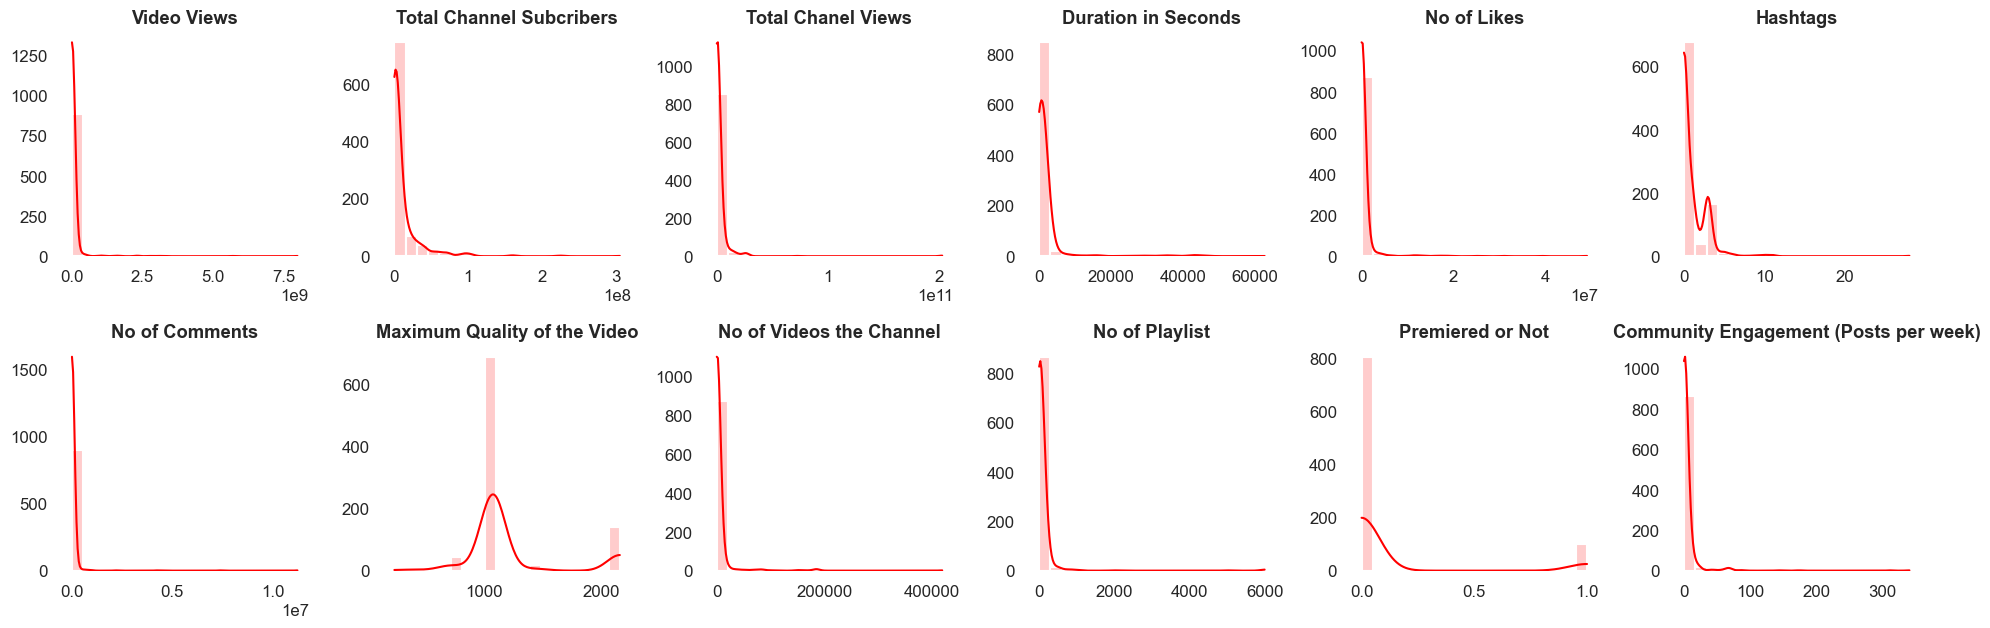

In [174]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 6, figsize=(24, 7), squeeze=False)

color = yt_palette["red"]

for i, col in enumerate(numerical_columns):
    row = i // 6
    col_idx = i % 6

    sns.histplot(df[col], bins=20, kde=True, alpha=0.2, color=color,
                 linewidth=1.5, ax=axes[row, col_idx])

    axes[row, col_idx].set_title(col)
    axes[row, col_idx].set_xlabel('')
    axes[row, col_idx].set_ylabel('')
    
plt.subplots_adjust(hspace=0.4, wspace=0.3)


In [175]:
import numpy as np


log_numeric_columns = []

# Apply log transformation to numerical columns and create new columns
for col in numerical_columns:
    df[f'Log {col}'] = np.log(df[col].replace(0, np.nan))
    log_numeric_columns.append(f'Log {col}')

df[log_numeric_columns].head()

,Log Video Views,Log Total Channel Subcribers,Log Total Chanel Views,Log Duration in Seconds,Log No of Likes,Log Hashtags,Log No of Comments,Log Maximum Quality of the Video,Log No of Videos the Channel,Log No of Playlist,Log Premiered or Not,Log Community Engagement (Posts per week)
0,11.891766,10.601622,15.890478,7.518064,8.809863,NaN,6.037871,6.984716,6.135565,2.484907,NaN,0.000000
1,12.354359,13.732129,18.739394,6.761573,8.961879,0.0,5.241747,6.984716,5.525453,2.484907,0.0,0.693147
2,6.777647,6.126869,11.197461,6.198479,6.754604,NaN,NaN,6.579251,5.062595,NaN,NaN,NaN
3,9.206834,14.334304,20.110137,4.189655,5.236442,NaN,4.343805,6.984716,10.747401,3.871201,NaN,2.995732
4,17.498889,16.308716,22.004337,6.131226,13.711261,NaN,10.247822,6.984716,7.962764,4.727388,NaN,0.000000


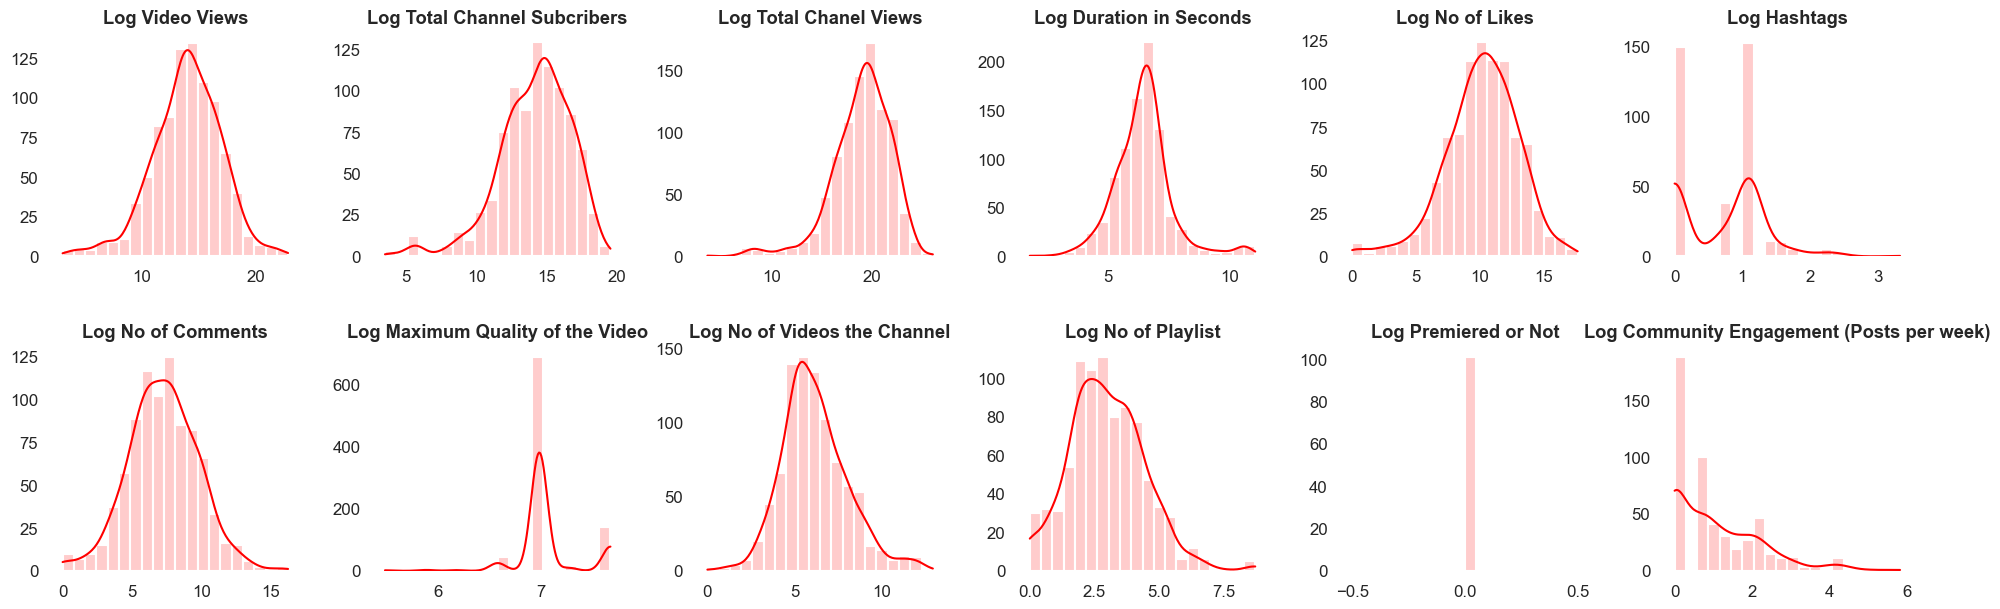

In [176]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 6, figsize=(24, 7), squeeze=False)

color = yt_palette["red"]

for i, col in enumerate(log_numeric_columns):
    row = i // 6
    col_idx = i % 6

    sns.histplot(df[col], bins=20, kde=True, alpha=0.2, color=color,
                 linewidth=1.5, ax=axes[row, col_idx])

    axes[row, col_idx].set_title(col)
    axes[row, col_idx].set_xlabel('')
    axes[row, col_idx].set_ylabel('')
    
plt.subplots_adjust(hspace=0.4, wspace=0.3)


As shown above, most numerical values now resemble normal distributions. The remaining features that do not appear normal are categorical. We can continue our process without applying any further transformations to the data distributions.

## Marketing Cost Calcualtion

We are artificially generating marketing costs for videos based on their view counts and applying a multiplication coefficient according to their subscriber counts, ranging from 0% to 10%. This allows us to enhance decision-making regarding cost-efficient marketing. Our analysis is designed to maximize engagement relative to spending.

In [177]:
# Desired interval
a, b = 0, 6

# Group means
group_means = df.groupby("Creator Name")["Log Video Views"].transform("mean")

# Min-Max Scaling
scaled_means = a + (group_means - group_means.min()) * (b - a) / (group_means.max() - group_means.min())

df["CPM"] = scaled_means


In [178]:
# Desired interval
a, b = 1, 1.1

# Group means
group_means = df.groupby("Creator Name")["Log Total Channel Subcribers"].transform("mean")

# Min-Max Scaling
scaled_means = a + (group_means - group_means.min()) * (b - a) / (group_means.max() - group_means.min())

# Yeni sütun olarak ekle
df["Sub Bonus"] = scaled_means


In [179]:
# Calculate Marketing Cost while adding "Sub Bonus"
df["Marketing Cost"] = (df["CPM"] * df["Video Views"]/1000) * df["Sub Bonus"]



## Bucketing by Log of Video Views

One of the main goals of this project is to understand and apply logistic regression, which requires predicting a binary outcome (0 or 1). To achieve this, we created buckets and identified the best ones to label as 1 (the target variable). This approach also makes it easier to estimate bucket categories rather than the exact view counts of videos.

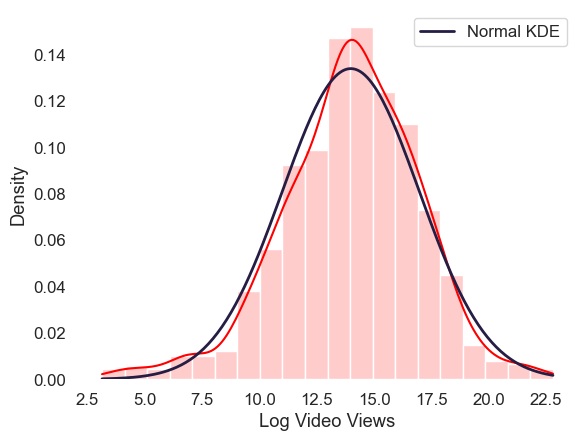

In [180]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

data = df["Log Video Views"].dropna()

sns.histplot(data, bins=20, kde=True, alpha=0.2,
             color=yt_palette["red"], linewidth=1, stat="density")

# Theorical normal distribution
mu, sigma = data.mean(), data.std()
x = np.linspace(data.min(), data.max(), 200)
pdf = norm.pdf(x, mu, sigma)

plt.plot(x, pdf, color=yt_palette["purple"], linewidth=2, label="Normal KDE")

plt.legend()
plt.show()


In [181]:
# First, we need to calculate our IQR.
q1 = df["Log Video Views"].quantile(0.25)                 
q3 = df["Log Video Views"].quantile(0.75)
iqr = q3 - q1

# Now let's calculate upper and lower bounds.
lower = q1 - 1.5*iqr
upper = q3 + 1.5*iqr

# Let us create our bins:
num_bins = 6
bin_width = (upper - lower) / num_bins
bins = [lower + i*bin_width for i in range(num_bins)]
bins += [upper, float('inf')]  # Now we add our last bin, which will contain any value greater than the upper-bound of the IQR.

# Let us create our labels:
labels = [f'Bucket {i}' for i in range(1,num_bins+1)]
labels.append('Outside IQR')

# Finally, we add a new column to the df:
df['Log Video Views Bucket'] = pd.cut(df["Log Video Views"], bins=bins, labels=labels)
df[["Log Video Views",'Log Video Views Bucket']]

,Log Video Views,Log Video Views Bucket
0,11.891766,Bucket 3
1,12.354359,Bucket 3
2,6.777647,Bucket 1
3,9.206834,Bucket 2
4,17.498889,Bucket 5
...,...,...
900,8.838117,Bucket 1
901,9.714383,Bucket 2
902,10.398123,Bucket 2
903,7.315218,Bucket 1


### Removing Outliers for Each Bucket

We are performing a trend analysis to identify the most efficient bucket, so we need to remove outliers from each bucket. To do this, we examine the distribution of each bucket and determine unique IQR-based coefficients for every column.

In [182]:
numeric_cols = ['Video Views', 'Marketing Cost', 'No of Likes', 'No of Comments']

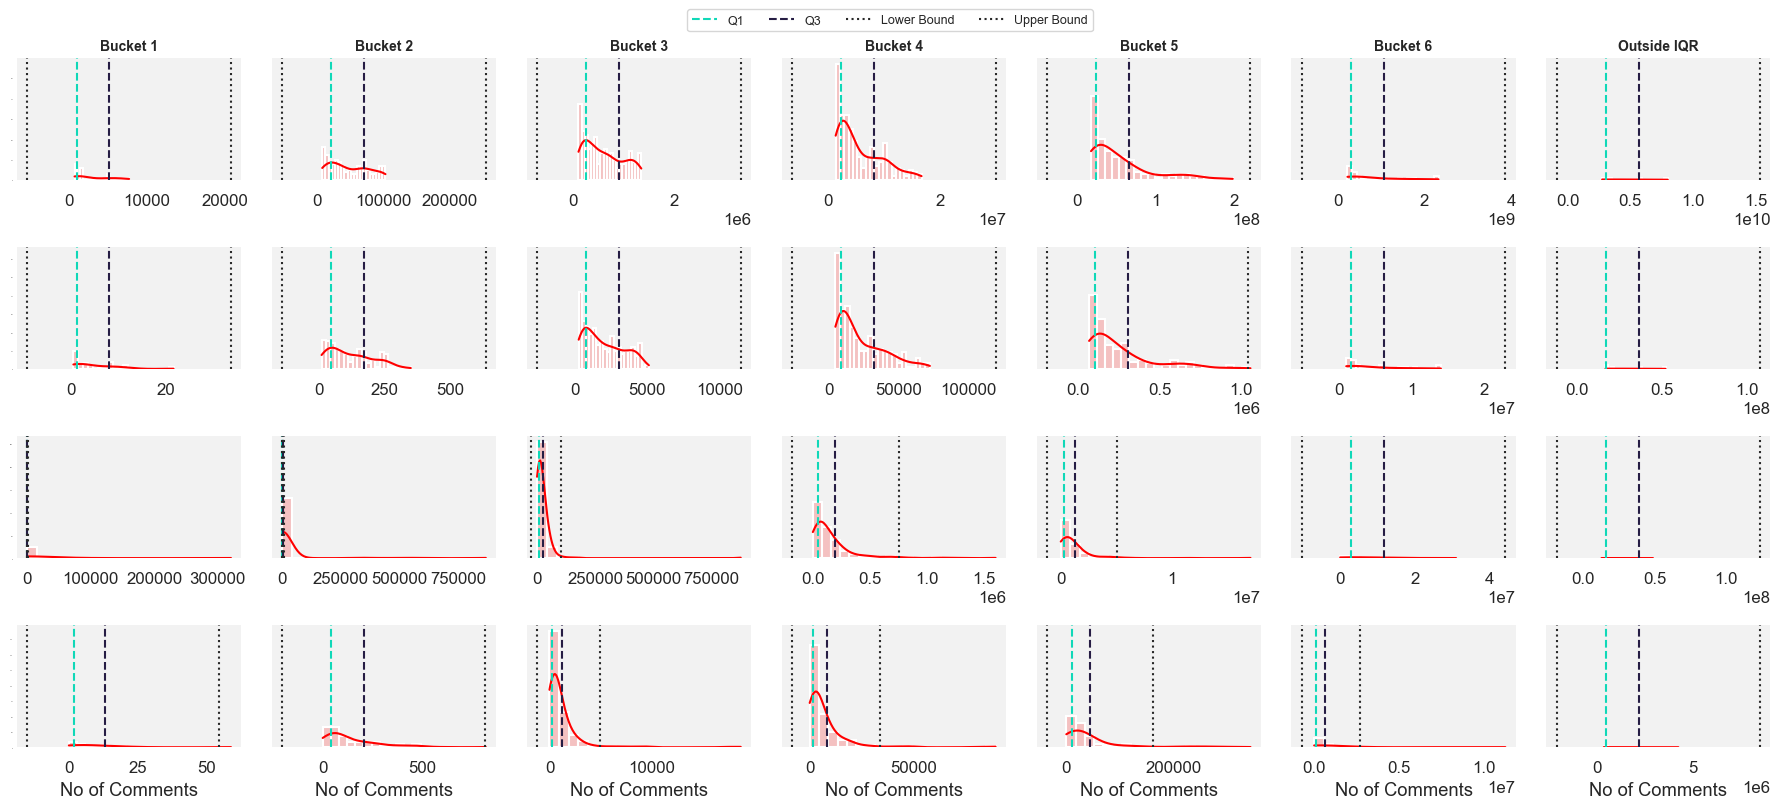

In [183]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(len(numeric_cols), len(labels), figsize=(18, 8), sharey='row')

for row, col_name in enumerate(numeric_cols):
    for col, label in enumerate(labels):
        ax = axes[row, col]
        subset = df[df['Log Video Views Bucket'] == label][col_name]
        
        ax.set_facecolor('#f2f2f2')  

        # Histogram with seaborn
        sns.histplot(subset, bins=20, kde=True, alpha=0.2, color=color,
                     linewidth=1.5, ax=ax)

        # --- IQR calculation ---
        Q1 = subset.quantile(0.25)
        Q3 = subset.quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 3.7 * IQR

        # Add vertical lines for IQR bounds
        ax.axvline(Q1, color=yt_palette['blue'], linestyle='--', linewidth=1.5, label='Q1')
        ax.axvline(Q3, color=yt_palette['purple'], linestyle='--', linewidth=1.5, label='Q3')
        ax.axvline(lower, color=yt_palette['black'], linestyle=':', linewidth=1.5, label='Lower Bound')
        ax.axvline(upper, color=yt_palette['black'], linestyle=':', linewidth=1.5, label='Upper Bound')

        # Titles and labels
        ax.set_title(label if row == 0 else "", fontsize=10)
        ax.set_xlabel(col_name if row == len(numeric_cols)-1 else "")
        ax.set_ylabel('')

        # Optional: hide ticks
        ax.tick_params(axis='y', which='both', length=0, labelsize=0)

# Add a single legend outside all plots
handles, labels_ = ax.get_legend_handles_labels()  # get from last ax
fig.legend(handles, labels_, loc='upper center', bbox_to_anchor=(0.5, 1.02),
           ncol=4, fontsize=9)


plt.tight_layout()
plt.show()


We determine the coefficients by testing different values and evaluating them using the plot above.

In [184]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler


# Define custom IQR coefficients for each column
iqr_coeffs = {
    'Video Views': (1.5,1.8),
    'Marketing Cost': (1.5,1.8),
    'No of Likes': (1.5,2.8),
    'No of Comments': (1.5,3.7)
}

# Function to remove outliers by IQR for each group with custom coefficients
def remove_outliers_iqr(df_group):
    for col in numeric_cols:
        
        Q1 = df_group[col].quantile(0.25)
        Q3 = df_group[col].quantile(0.75)
        IQR = Q3 - Q1
        low , up = iqr_coeffs.get(col)
        lower_bound = Q1 - low * IQR
        upper_bound = Q3 + up * IQR
        df_group = df_group[(df_group[col] >= lower_bound) & (df_group[col] <= upper_bound)]
        
     
    return df_group

print("Before outlier removal:", df.shape[0])
print("After outlier removal:", df.groupby("Log Video Views Bucket").apply(remove_outliers_iqr).reset_index(drop=True).shape[0])

# Apply group-wise outlier removal
df = df.groupby("Log Video Views Bucket").apply(remove_outliers_iqr).reset_index(drop=True)



Before outlier removal: 905
After outlier removal: 817


/var/folders/6j/1nsywzcs1v5_6gn_3972hssr0000gn/T/ipykernel_7660/2571225308.py:29: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print("After outlier removal:", df.groupby("Log Video Views Bucket").apply(remove_outliers_iqr).reset_index(drop=True).shape[0])
/var/folders/6j/1nsywzcs1v5_6gn_3972hssr0000gn/T/ipykernel_7660/2571225308.py:29: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  print("After outlier removal:", df.groupby("Log Video Views Bucket").apply(remove_outliers_iqr).reset_index(drop=True).shape[0])
/var

After removing 87 data points, the distribution has improved significantly. We can now continue with our analysis.

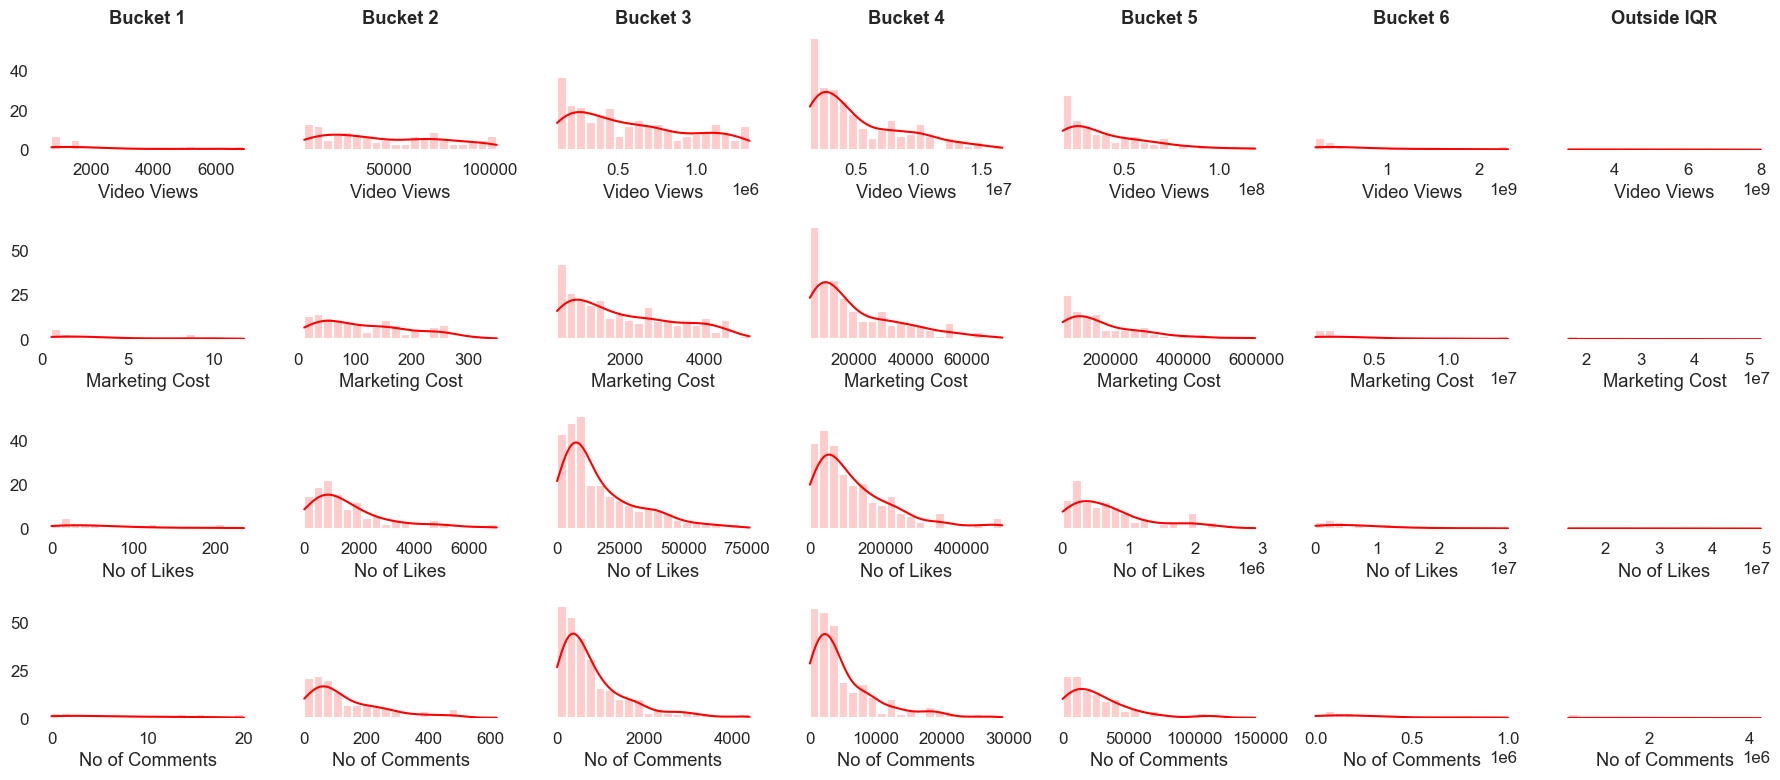

In [185]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(len(numeric_cols), len(labels), figsize=(18, 8), sharey='row')

for row, col_name in enumerate(numeric_cols):
    for col, label in enumerate(labels):
        ax = axes[row, col]
        subset = df[df['Log Video Views Bucket'] == label][col_name]

        sns.histplot(subset, bins=20, kde=True, alpha=0.2, color=color,
                 linewidth=1.5, ax=ax)
        
        ax.set_title(label if row == 0 else "")
        ax.set_xlabel(col_name)
        
        ax.set_ylabel('')

plt.tight_layout()
plt.show()

## Bucket Analysis

In [186]:
# Deleting outliers
test_data = df[df["Log Video Views Bucket"] != "Outside IQR"].dropna(subset=["Log Video Views Bucket"]).copy()


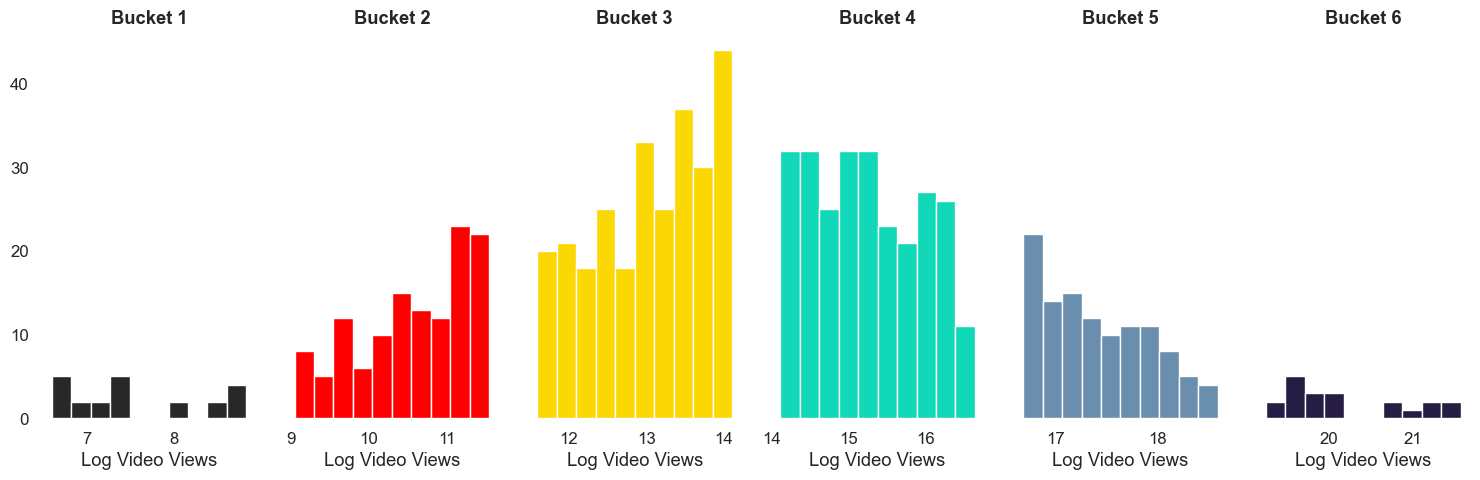

In [187]:
custom_colors = list(yt_palette.values())

fig, axes = plt.subplots(1, len(labels[:-1]), figsize=(15, 5), sharey=True)
for i, label in enumerate(labels[:-1]):
    ax = axes[i]
    subset = test_data[test_data['Log Video Views Bucket'] == label]['Log Video Views']
    ax.hist(subset, bins=10, color=custom_colors[i])
    ax.set_title(label)
    ax.set_xlabel('Log Video Views')
    ax.set_ylabel('')

plt.tight_layout()
plt.show()


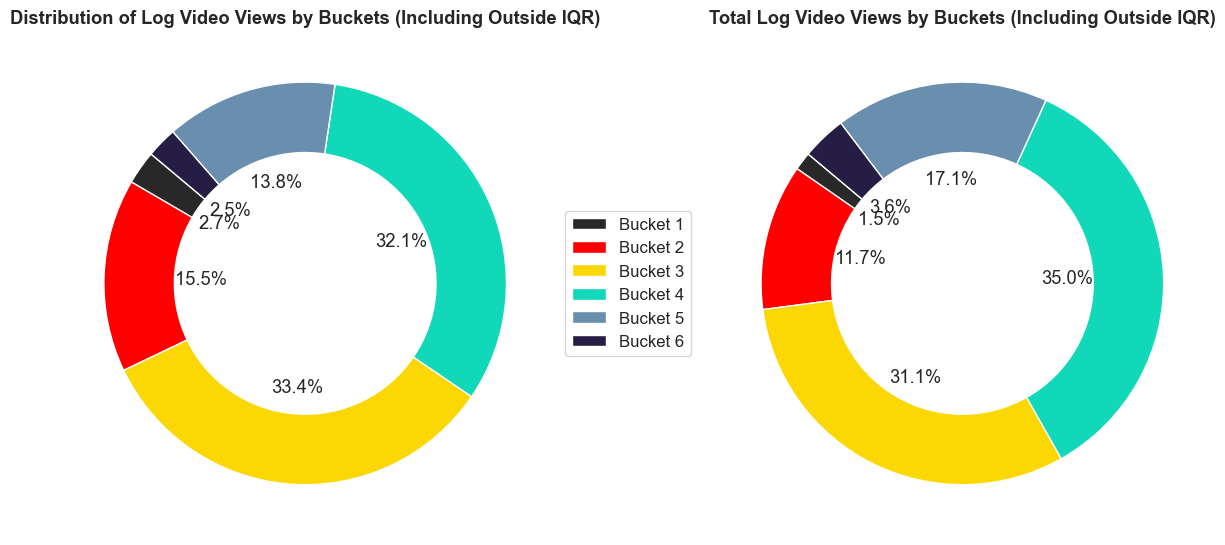

In [188]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))  # boyutu biraz büyüttüm

# Calculate counts and sums for each bucket
bucket_counts = test_data.groupby('Log Video Views Bucket', observed=True)['Log Video Views'].count().reindex(labels[:-1]).copy()
bucket_sums = test_data.groupby('Log Video Views Bucket', observed=True)['Log Video Views'].sum().reindex(labels[:-1]).copy()


# Pie chart for bucket counts
axes[0].pie(bucket_counts, labels=None, autopct='%1.1f%%', startangle=140,
            colors=custom_colors[:len(labels[:-1])], pctdistance=0.52,wedgeprops=dict(width=0.35))
axes[0].set_title('Distribution of Log Video Views by Buckets (Including Outside IQR)')
axes[0].legend(labels, loc="center left", bbox_to_anchor=(1, 0.5))

# Pie chart for bucket sums
axes[1].pie(bucket_sums, labels=None, autopct='%1.1f%%', startangle=140,
            colors=custom_colors[:len(labels[:-1])], pctdistance=0.52,wedgeprops=dict(width=0.35))
axes[1].set_title('Total Log Video Views by Buckets (Including Outside IQR)')


plt.tight_layout()
plt.show()


In [189]:
test_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 812 entries, 0 to 811
Data columns (total 45 columns):
 #   Column                                     Non-Null Count  Dtype         
---  ------                                     --------------  -----         
 0   Video Views                                812 non-null    int64         
 1   Channel URL                                812 non-null    object        
 2   Creator Name                               812 non-null    object        
 3   Creator Gender                             512 non-null    object        
 4   Total Channel Subcribers                   811 non-null    float64       
 5   Total Chanel Views                         804 non-null    float64       
 6   Duration of Video                          812 non-null    object        
 7   Duration in Seconds                        812 non-null    float64       
 8   Date of Video Upload                       812 non-null    datetime64[ns]
 9   No of Likes               

In [190]:
bucket_names = labels[:-1]

## Determining the Best Bucket

In [191]:
bucket_analysis = test_data[[ "Marketing Cost", "Video Views", "No of Likes", "No of Comments","Log Video Views Bucket"]].copy().dropna()
bucket_analysis.info()

<class 'pandas.core.frame.DataFrame'>
Index: 812 entries, 0 to 811
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   Marketing Cost          812 non-null    float64 
 1   Video Views             812 non-null    int64   
 2   No of Likes             812 non-null    float64 
 3   No of Comments          812 non-null    int64   
 4   Log Video Views Bucket  812 non-null    category
dtypes: category(1), float64(2), int64(2)
memory usage: 32.9 KB


To facilitate visualization of scatter plots and trend analysis, we are scaling all features to the same range.

In [192]:
# Scale numeric columns after outlier removal

numeric_cols = ["Marketing Cost", "Video Views", "No of Likes", "No of Comments"]

scaler = MinMaxScaler(feature_range=(0, 1_000_000))
scaled_values = scaler.fit_transform(bucket_analysis[numeric_cols])

bucket_analysis[numeric_cols] = scaled_values

bucket_analysis.describe()

,Marketing Cost,Video Views,No of Likes,No of Comments
count,812.000000,812.000000,812.000000,812.000000
mean,10478.662013,11897.836358,11215.356547,13524.357143
std,69063.177784,70735.734080,58753.346852,68189.014980
min,0.000000,0.000000,0.000000,0.000000
25%,46.714298,92.355059,167.741935,235.250000
50%,308.581155,548.519206,870.967742,1100.000000
75%,2064.157127,3240.562910,4424.209677,4983.500000
max,1000000.000000,1000000.000000,1000000.000000,1000000.000000


### Understanding Bucket Characteristics

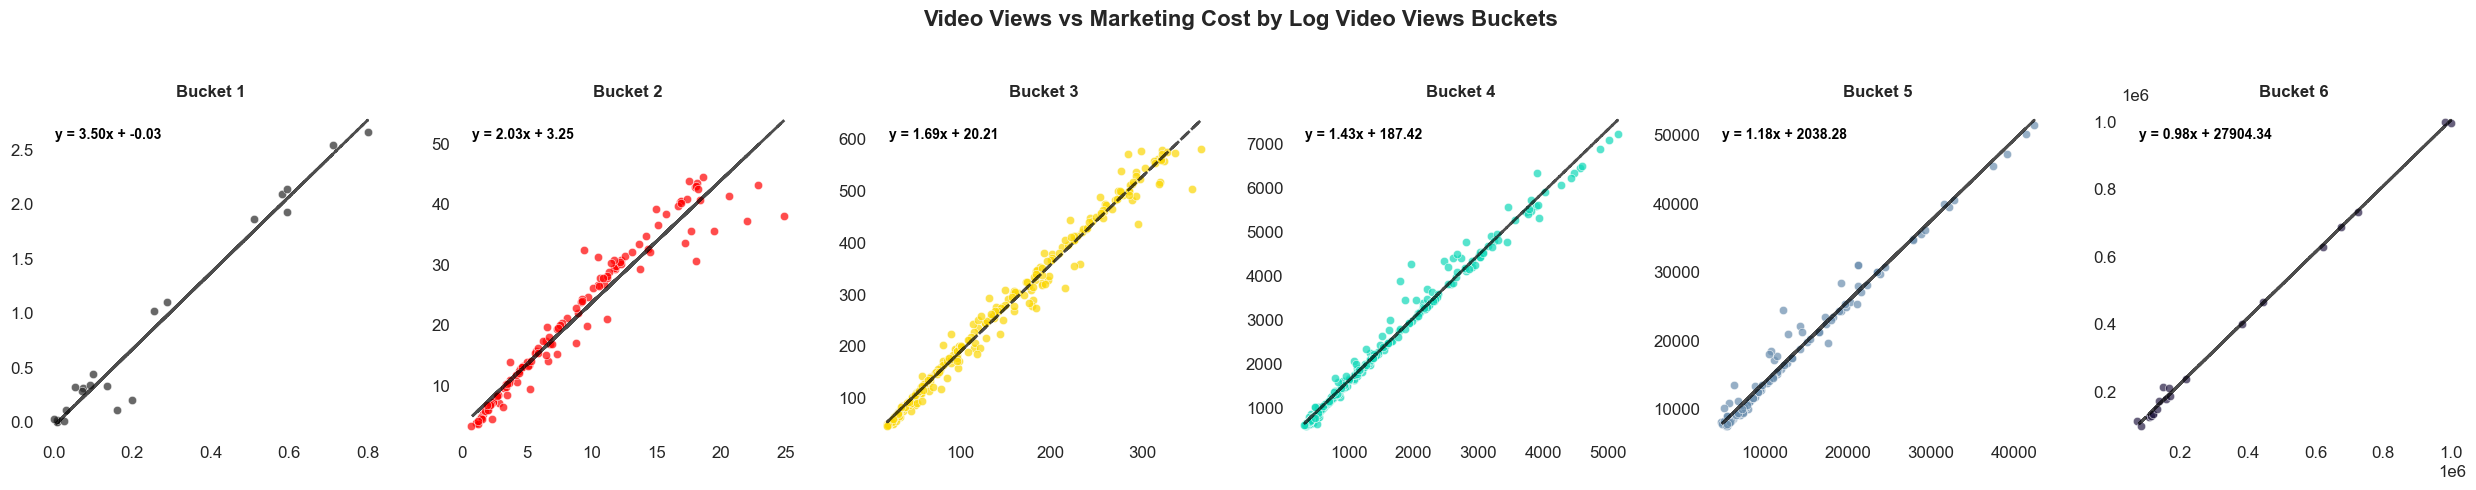

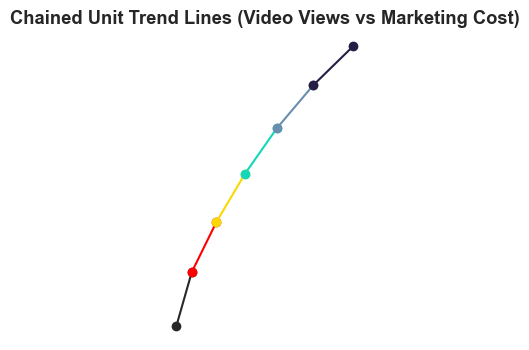

In [193]:
import utils

utils.plot_bucket_trends(bucket_analysis, bucket_names, yt_palette,
                   x_col="Marketing Cost", y_col="Video Views",
                   show_axes=False,figsize_chain=(4,4))


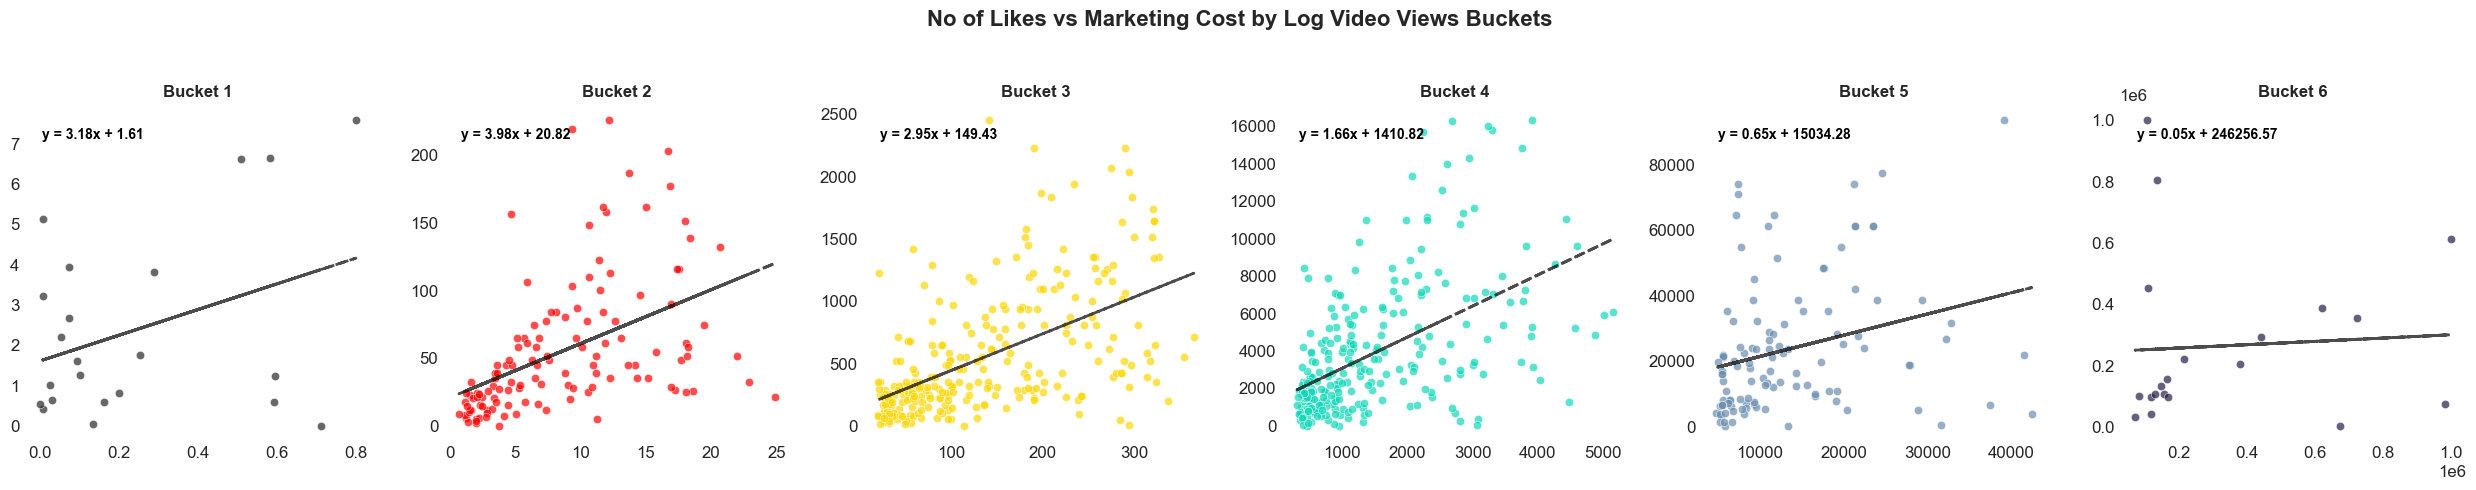

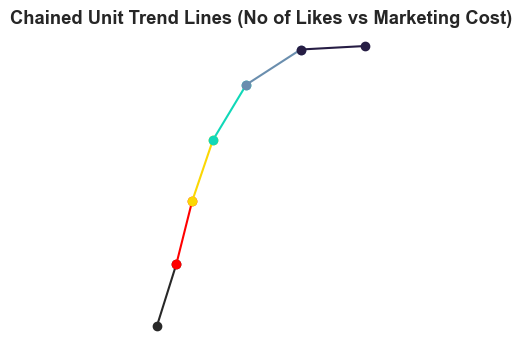

In [194]:
utils.plot_bucket_trends(bucket_analysis, bucket_names, yt_palette,
                   x_col="Marketing Cost", y_col="No of Likes",
                   show_axes=False,figsize_chain=(4,4))

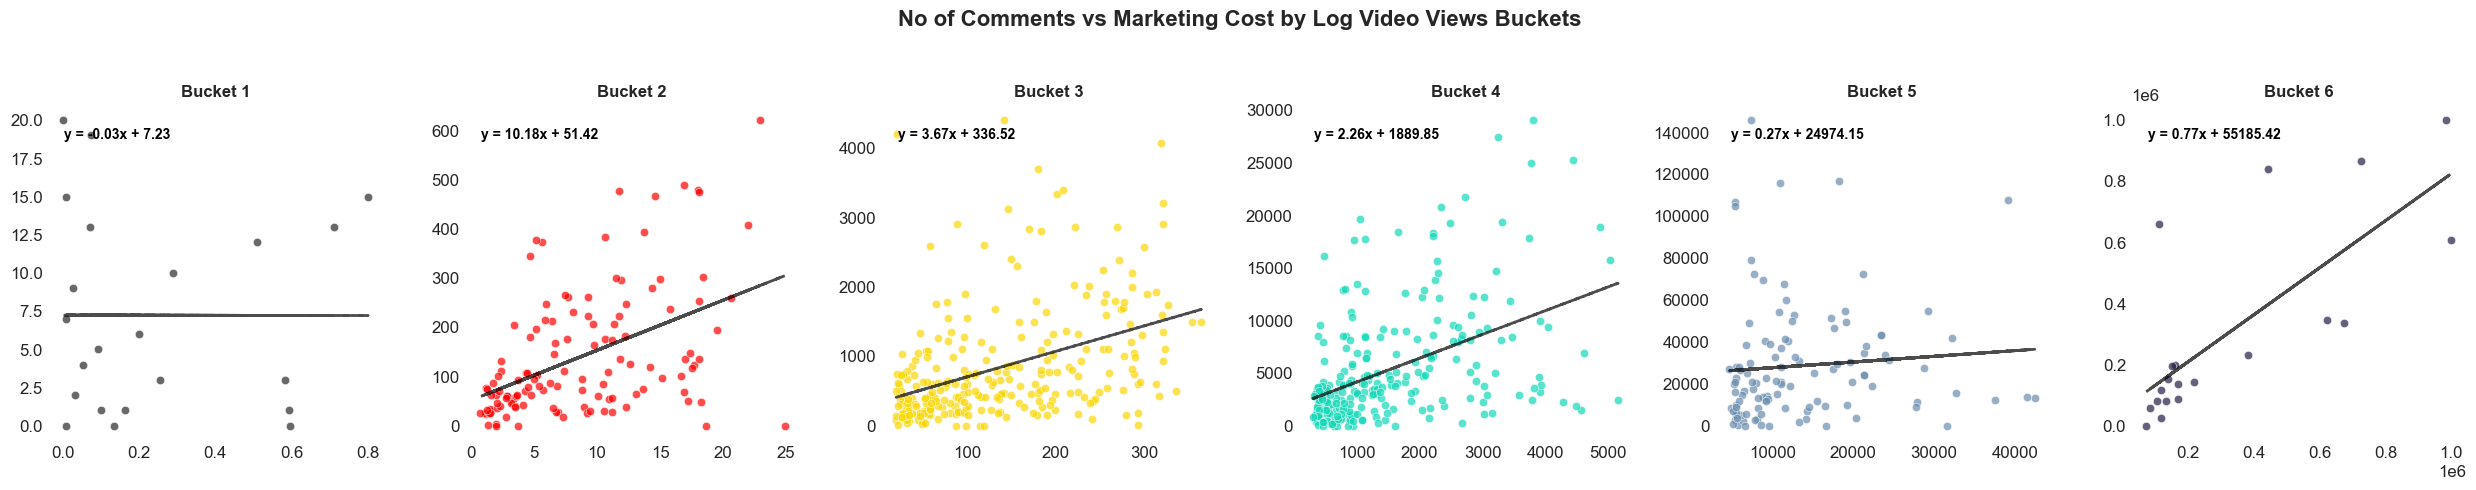

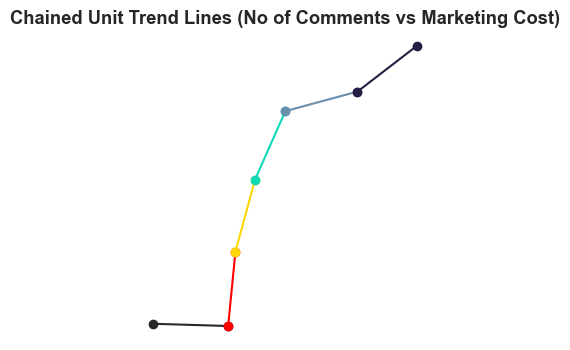

In [195]:
utils.plot_bucket_trends(bucket_analysis, bucket_names, yt_palette,
                   x_col="Marketing Cost", y_col="No of Comments",
                   show_axes=False,figsize_chain=(4,4))

Efficiency decreases with bucket 5. The last best-performing buckets are 3 and 4, but we cannot use them together because a good model requires evenly distributed categories. Therefore, we are selecting buckets 2 and 3 as our target variables, labeling them as 1, while the others will be labeled as 0 later in the project.

## Feature Creation

### Atractness Score
This feature is designed to understand whether the channel attracts non-subscriber accounts.

<Axes: xlabel='Atractness Score', ylabel='Count'>

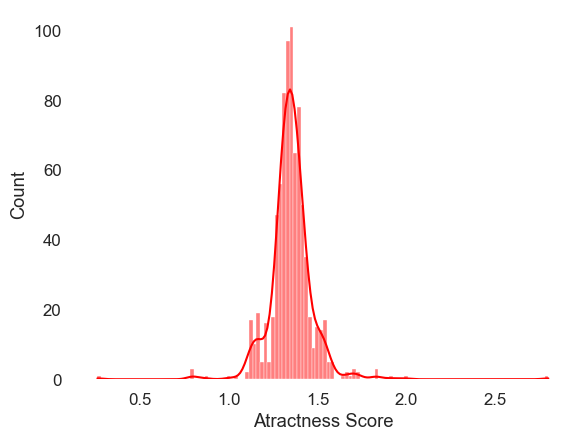

In [196]:
df["Atractness Score"] =  df["Log Total Chanel Views"] / df["Log Total Channel Subcribers"] 

sns.histplot(data=df, x="Atractness Score", kde=True, color=yt_palette["red"])

### Efficiency Score
This feature is designed to measure the efficiency of videos in terms of attracting views.

<Axes: xlabel='Efficiency Score', ylabel='Count'>

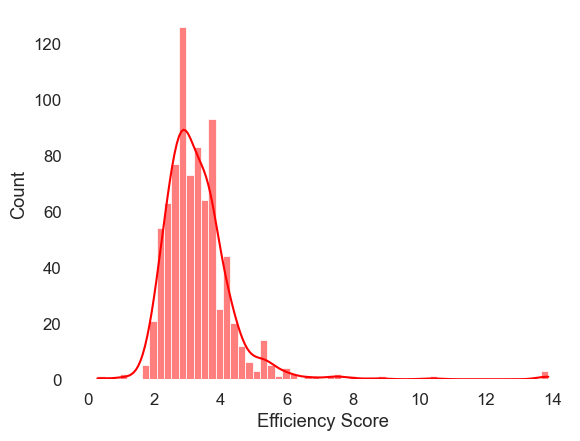

In [197]:
df["Efficiency Score"] =  df["Log Total Chanel Views"] / df["Log No of Videos the Channel"] 

sns.histplot(data=df, x="Efficiency Score", kde=True,color=yt_palette["red"])

In [198]:
df[["Creator Name","Efficiency Score"]].sort_values(by="Efficiency Score", ascending=False).head(10)

,Creator Name,Efficiency Score
715,Anubhav Singh Bassi,13.886011
788,Anubhav Singh Bassi,13.885159
520,Blockshelf,13.784393
13,Udyansh Society,10.369597
650,Court Room,8.764751
32,America Chowrasta FinTech,7.965034
699,Steve Cutts,7.554919
433,Varun Grover,7.493355
91,Rob Hamilton,7.352156
744,Abhishek Upmanyu,6.785325


### Sub Per Video
This feature is designed to measure how efficiently the channel gains subscribers.

<Axes: xlabel='Sub Per Video', ylabel='Count'>

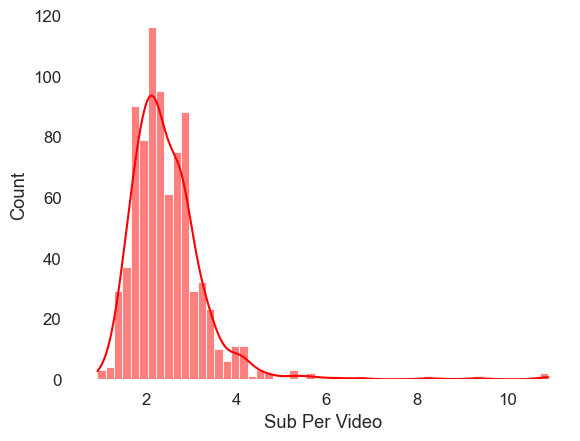

In [199]:
df["Sub Per Video"] =  df["Log Total Channel Subcribers"] / df["Log No of Videos the Channel"] 

sns.histplot(data=df, x="Sub Per Video", kde=True, color=yt_palette["red"])

In [200]:
df[["Creator Name","Sub Per Video"]].sort_values(by="Sub Per Video", ascending=False).head(10)

,Creator Name,Sub Per Video
788,Anubhav Singh Bassi,10.911494
715,Anubhav Singh Bassi,10.911494
520,Blockshelf,9.340112
13,Udyansh Society,8.285402
433,Varun Grover,6.700816
32,America Chowrasta FinTech,6.174917
699,Steve Cutts,5.717540
650,Court Room,5.638308
91,Rob Hamilton,5.363646
744,Abhishek Upmanyu,5.270529


### Subtitle

In [201]:
df['Subtitle'] = df['Subtitle'].replace('yes', 'Yes')
df = pd.get_dummies(df, columns=['Subtitle'], drop_first=True)


### Language

In [202]:
df["Language of the Video"].value_counts(dropna=False)
df["Is_Eng"] = df["Language of the Video"].apply(lambda x: 1 if x == "English" else 0)

# Exporting the Data

In [203]:
df.columns

Index(['Video Views', 'Channel URL', 'Creator Name', 'Creator Gender',
       'Total Channel Subcribers', 'Total Chanel Views', 'Duration of Video',
       'Duration in Seconds', 'Date of Video Upload', 'No of Likes',
       'Language of the Video', 'Video Description', 'Hashtags',
       'No of Comments', 'Date of the Last Comment',
       'Maximum Quality of the Video', 'No of Videos the Channel',
       'No of Playlist', 'Premiered or Not',
       'Community Engagement (Posts per week)', 'DayOfWeek', 'Friday',
       'Monday', 'Saturday', 'Sunday', 'Thursday', 'Tuesday', 'Wednesday',
       'Log Video Views', 'Log Total Channel Subcribers',
       'Log Total Chanel Views', 'Log Duration in Seconds', 'Log No of Likes',
       'Log Hashtags', 'Log No of Comments',
       'Log Maximum Quality of the Video', 'Log No of Videos the Channel',
       'Log No of Playlist', 'Log Premiered or Not',
       'Log Community Engagement (Posts per week)', 'CPM', 'Sub Bonus',
       'Marketing Cost',

In [204]:
df.to_csv("youtube_influencers_data_cleaned.csv", index=False)